In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score

# load results data

In [2]:
df_w = pd.read_csv('../results/feature_selection_with_intercept.csv')
df_wo = pd.read_csv('../results/feature_selection_without_intercept.csv')
df_w['intercept'] = 'Y'
df_wo['intercept'] = 'N'
df = pd.concat([df_w, df_wo], ignore_index=True)
df.sort_values('malr', ascending=True).reset_index(drop=True)

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr,intercept
0,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",15,0.371955,0.008017,0.829372,0.375021,-0.004822,0.829349,0.433855,...,-0.134832,0.795591,0.405130,0.078069,0.797464,0.402761,0.025771,0.808689,0.025771,Y
1,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",14,0.372011,0.007871,0.829335,0.375131,-0.005083,0.829288,0.433787,...,-0.135227,0.795423,0.405181,0.077821,0.797356,0.402827,0.025504,0.808617,0.025504,Y
2,Y,"Log_Tot_Mdcr_Pymt_Amt,current_year,Log_Tot_Mdc...",14,0.371935,0.009372,0.829217,0.374992,-0.003322,0.829167,0.434241,...,-0.133338,0.795470,0.405545,0.080230,0.797005,0.402845,0.027423,0.808439,0.027423,N
3,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",13,0.372028,0.008058,0.829227,0.375141,-0.004846,0.829161,0.433683,...,-0.135324,0.795219,0.405344,0.077977,0.797178,0.402876,0.025665,0.808481,0.025665,Y
4,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",15,0.372095,0.007995,0.829305,0.375137,-0.004835,0.829291,0.434136,...,-0.134846,0.795510,0.405335,0.078152,0.797384,0.402921,0.025781,0.808616,0.025781,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2792,Y,Tot_Mdcr_Pymt_Amt,1,inf,inf,-47.534704,inf,inf,-48.013389,inf,...,inf,-50.836684,inf,inf,-49.778756,inf,inf,-48.441255,inf,N
2793,Y,Tot_Mdcr_Alowd_Amt,1,inf,inf,-46.822061,inf,inf,-47.352548,inf,...,inf,-50.242273,inf,inf,-49.209210,inf,inf,-47.807621,inf,N
2794,Y,Tot_Sbmtd_Chrg,1,inf,inf,-48.278466,inf,inf,-48.522599,inf,...,inf,-51.306921,inf,inf,-50.176190,inf,inf,-48.972487,inf,N
2795,Y,Tot_Srvcs,1,10.311317,-10.299145,-49.219043,10.318960,-10.304858,-49.656948,inf,...,-10.334085,-52.334437,10.269113,-10.259815,-50.988815,inf,inf,-50.000292,inf,N


## select best models within their kind

In [3]:
# make sure if best model is log, the features does not contain non-logged Tot features
def best_model(df,log = 'Y'):
    if log == 'Y':
        i = 0
        features = df[df['log']==log].sort_values('R2',ascending=False).reset_index(drop=True).loc[i,:]['features'].split(',')
        # filter out Tot features that are not logged, and pca_1
        while any([f for f in features if f.startswith('Tot_') and f!='Tot_HCPCS_Cds']) or any([f for f in features if f=='pca_1']):
            i += 1
            features = df[df['log']==log].sort_values('R2',ascending=False).reset_index(drop=True).loc[i,:]['features'].split(',')
    else:
        i = 0
        features = df[df['log']==log].sort_values('R2',ascending=False).reset_index(drop=True).loc[0,:]['features'].split(',')
    model_data = df[df['log']==log].sort_values('R2',ascending=False).reset_index(drop=True).loc[i,:]
    return features, model_data


In [4]:
log_w = best_model(df_w, log='Y')[1]
nonlog_w = best_model(df_w, log='N')[1]
log_wo = best_model(df_wo, log='Y')[1]
nonlog_wo = best_model(df_wo, log='N')[1]
final_models = pd.DataFrame([log_w, nonlog_w, log_wo, nonlog_wo]).reset_index(drop=True)
final_models

,log,features,num_features,malr_2018,mlr_2018,R2_2018,malr_2019,mlr_2019,R2_2019,malr_2020,...,mlr_2021,R2_2021,malr_2022,mlr_2022,R2_2022,malr,mlr,R2,abs_mlr,intercept
0,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",15,0.372383,0.007683,0.829208,0.375487,-0.005365,0.829177,0.434852,...,-0.135480,0.794992,0.405626,0.077769,0.797544,0.403325,0.025325,0.808485,0.025325,Y
1,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Cd_O...",10,0.480710,0.285427,0.930564,0.443958,0.217127,0.881968,0.545050,...,0.063317,0.869404,0.456435,0.218178,0.902358,0.470727,0.235161,0.894474,0.235161,Y
2,Y,"Log_Tot_Mdcr_Pymt_Amt,current_year,Log_Tot_Mdc...",14,0.372380,0.009009,0.829052,0.375379,-0.003731,0.829068,0.435480,...,-0.133528,0.795293,0.406152,0.080191,0.796929,0.403410,0.027148,0.808288,0.027148,N
3,N,"Tot_Mdcr_Pymt_Amt,LabPathology_Tot_Risk_0,Type...",7,0.379851,-0.009688,0.930782,0.376831,-0.006556,0.881945,0.451919,...,-0.133693,0.869418,0.415036,0.083105,0.902361,0.412920,0.023417,0.894523,0.023417,N


## best model based on walkforward malr

In [5]:
# best model data
best_model = final_models.sort_values('malr',ascending=True).reset_index(drop=True).loc[0,:]
best_model

log                                                             Y
features        Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...
num_features                                                   15
malr_2018                                                0.372383
mlr_2018                                                 0.007683
R2_2018                                                  0.829208
malr_2019                                                0.375487
mlr_2019                                                -0.005365
R2_2019                                                  0.829177
malr_2020                                                0.434852
mlr_2020                                                 0.182016
R2_2020                                                  0.791503
malr_2021                                                0.428276
mlr_2021                                                 -0.13548
R2_2021                                                  0.794992
malr_2022 

In [ ]:
best_model.to_csv('../results/best_model_metric_evaluation.csv', index=False)

# Test on Best Model

In [32]:
def mean_abs_log_ratio(actual,pred):
    if min(actual)<=0:
        m = sorted(actual.unique())[1]
    else: m = min(actual)
    actual = actual.apply(lambda x:x if x>0 else m)

    if min(pred)<=0:
        m = sorted(pred.apply(lambda x:x if x>0 else 0).unique())[1]
        pred = pred.apply(lambda x:x if x>0 else m)
    ratio = pred/actual
    return np.mean(np.abs(np.log(ratio)))

def mean_log_ratio(actual,pred):
    if min(actual)<=0:
        m = sorted(actual.unique())[1]
    else: m = min(actual)
    actual = actual.apply(lambda x:x if x>0 else m)

    if min(pred)<=0:
        m = sorted(pred.apply(lambda x:x if x>0 else 0).unique())[1]
        pred = pred.apply(lambda x:x if x>0 else m)
    ratio = pred/actual
    return np.mean(np.log(ratio))

def check_model(feature_cols,df,target_col):
    result = pd.DataFrame({})

    features = ''
    for c in feature_cols:
        features+=f'{c},'
    features = features[:-1]

    boo = ''

    X_train = sm.add_constant(df[df['current_year']<2023][feature_cols])
    X_test = sm.add_constant(df[df['current_year']==2023][feature_cols])

    y_train = df[df['current_year']<2023][target_col]

    LR = sm.OLS(y_train,X_train).fit()

    if 'Log_' in target_col:
        boo = 'Y'
        log_pred = LR.predict(X_test)
        y_pred = np.exp(log_pred)
        log_test = df[df['current_year']==2023][target_col]
        y_test = df[df['current_year']==2023][f'{target_col[4:]}']
    else:
        boo = 'N'
        y_pred = LR.predict(X_test)
        y_test = df[df['current_year']==2023][target_col]

    result['log'] = [boo]
    result['intercept'] = ['Y']
    result['features'] = [features]
    result['num_features'] = [len(feature_cols)]
    result['malr'] = [round(mean_abs_log_ratio(y_test,y_pred),8)]
    result['mlr'] = [round(mean_log_ratio(y_test,y_pred),8)]
    if 'Log_' in target_col:
        result['R2(log)'] = [round(r2_score(log_test,log_pred),8)]
    else: result['R2(log)'] = [np.nan]
    result['R2'] = [round(r2_score(y_test,y_pred),8)]

    fig, ax = plt.subplots(2, 1, figsize=(8,16))

    mn = min(min(log_test),min(log_pred))
    mx = max(max(log_test),max(log_pred))

    ax[0].scatter(log_test,log_pred,alpha=0.5)
    ax[0].plot([mn, mx], [mn, mx], 'r-', linewidth=1)
    ax[0].set_xlim(mn,mx)
    ax[0].set_ylim(mn,mx)
    ax[0].set_xlabel('year 2023 actual log spending')
    ax[0].set_ylabel('year 2023 predicted log spending')
    ax[0].set_title('actual vs predicted log spending (1 year lag)')

    mn = min(min(y_test),min(y_pred))
    mx = max(max(y_test),max(y_pred))

    ax[1].scatter(y_test,y_pred,alpha=0.5)
    ax[1].plot([mn, mx], [mn, mx], 'r-', linewidth=2)
    ax[1].set_xlim(mn,mx)
    ax[1].set_ylim(mn,mx)
    ax[1].set_xlabel('year 2023 actual spending')
    ax[1].set_ylabel('year 2023 predicted spending')
    ax[1].set_title('actual vs predicted (1 year lag)')

    print(LR.summary())

    return result, LR


In [10]:
# load data
df = pd.read_csv('/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project/Modeling/common_NPI_pushed_year_finished_cat_with_Log_11.csv').drop(columns=['Unnamed: 0'])

In [11]:
best_features = best_model['features'].split(',')
best_target_col = 'Log_Tot_Mdcr_Pymt_Amt_current'

                                  OLS Regression Results                                 
Dep. Variable:     Log_Tot_Mdcr_Pymt_Amt_current   R-squared:                       0.821
Model:                                       OLS   Adj. R-squared:                  0.821
Method:                            Least Squares   F-statistic:                 2.763e+06
Date:                           Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                                   20:30:37   Log-Likelihood:            -8.5627e+06
No. Observations:                        9061686   AIC:                         1.713e+07
Df Residuals:                            9061670   BIC:                         1.713e+07
Df Model:                                     15                                         
Covariance Type:                       nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---

,log,intercept,features,num_features,malr,mlr,R2(log),R2
0,Y,Y,"Log_Tot_Mdcr_Pymt_Amt,Log_Tot_Mdcr_Alowd_Amt,T...",15,0.401575,0.032317,0.804422,0.589175


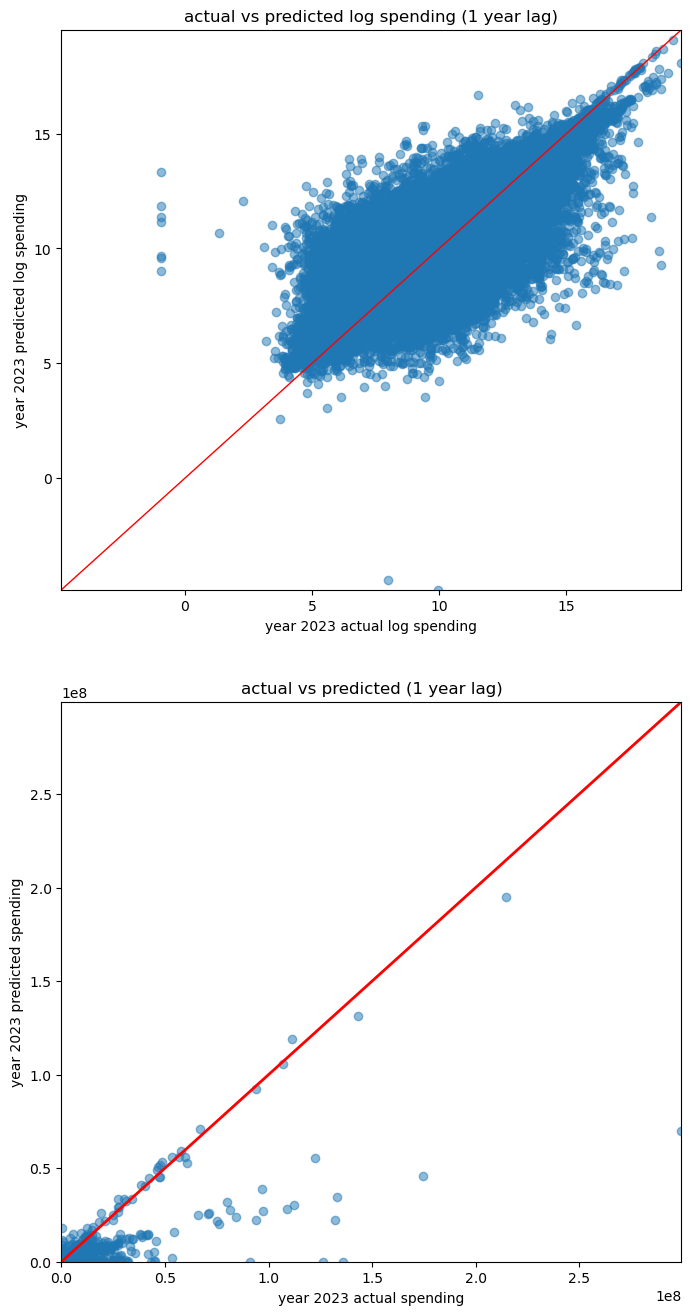

In [33]:
result, BEST_MODEL = check_model(best_features, df, best_target_col)
result

In [66]:
coef = BEST_MODEL.params.sort_values(ascending=False)
coef

Log_Tot_Mdcr_Pymt_Amt           1.366728
const                           0.703736
PharmacyNutrition_Tot_Risk_2    0.302226
Type_Cardiology                 0.124850
APP_Tot_Risk_2                  0.089772
Type_MedicalSpecialtyOther      0.070648
PrimaryCare_Tot_Risk_2          0.036135
Bene_Avg_Age                    0.005862
Tot_HCPCS_Cds                   0.001603
Log_Tot_Benes                  -0.070032
Type_BehavioralHealth          -0.103563
Type_RehabTherapy              -0.113456
Type_Anesthesia                -0.170014
Type_OBGYN                     -0.252797
state_Territory                -0.272587
Log_Tot_Mdcr_Alowd_Amt         -0.468265
dtype: float64

In [ ]:
coef.to_csv('../results/best_model_coefficients.csv')